## Comparison between multiple experiments

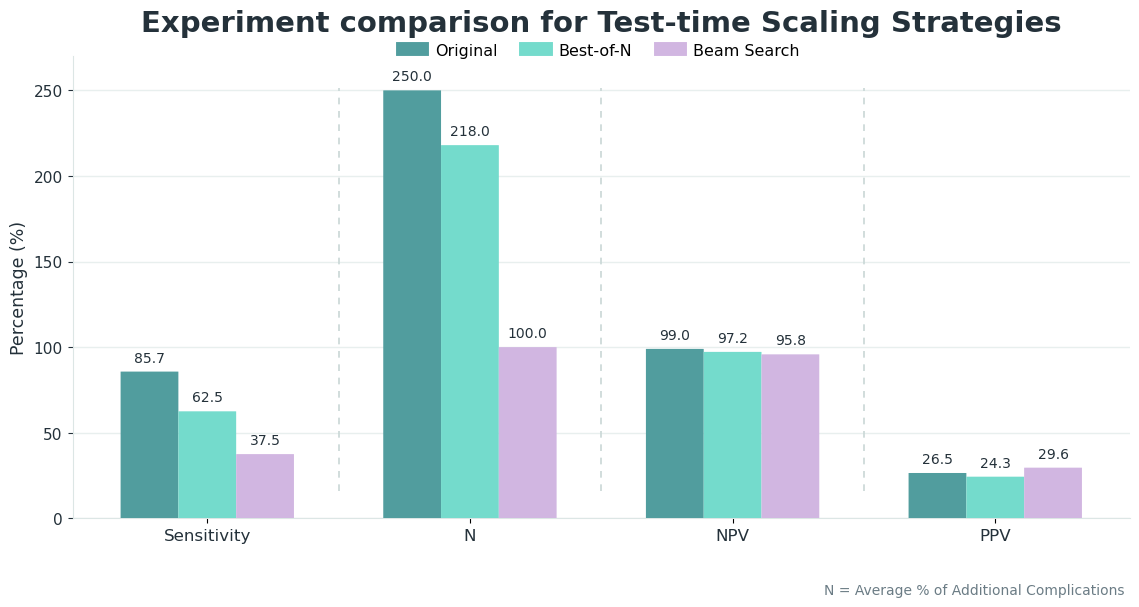

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

# Fill in your observation
df = pd.DataFrame({
    "Metric": ["Sensitivity", "N", "NPV", "PPV"],
    "Original": [85.71, 250.00, 98.97, 26.47],
    "Best-of-N": [62.50, 218.00, 97.22, 24.31],
    "Beam Search": [37.50, 100.00, 95.78, 29.58],
})

C1 = "#519D9E"   # Color 01
C3 = "#74DBCC"   # Color 03
C5 = "#D1B6E1"   # Color 05

TEXT = "#24313A"
SUBTLE = "#6B7C85"
GRID = "#E8EFEE"
SPINE = "#DCE6E5"
SEP = "#C9D7D6"
BG = "white"

fig, ax = plt.subplots(figsize=(11.5, 6.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

x = np.arange(len(df["Metric"]))
width = 0.22

# First draw invisible bars to get positions
bars1 = ax.bar(x - width, df["Original"], width=width, color="none", edgecolor="none", zorder=3)
bars2 = ax.bar(x,         df["Best-of-N"], width=width, color="none", edgecolor="none", zorder=3)
bars3 = ax.bar(x + width, df["Beam Search"], width=width, color="none", edgecolor="none", zorder=3)

def rounded_bars(bar_container, color):
    rounded = []
    for bar in bar_container:
        x0 = bar.get_x()
        y0 = bar.get_y()
        bw = bar.get_width()
        bh = bar.get_height()
        patch = FancyBboxPatch(
            (x0, y0),
            bw,
            bh,
            boxstyle="round,pad=0,rounding_size=0.02",
            linewidth=0,
            facecolor=color,
            zorder=3
        )
        ax.add_patch(patch)
        rounded.append((x0, bw, bh))
    return rounded

r1 = rounded_bars(bars1, C1)
r2 = rounded_bars(bars2, C3)
r3 = rounded_bars(bars3, C5)

# Value labels
def add_labels(rounded):
    for x0, bw, h in rounded:
        ax.text(
            x0 + bw / 2,
            h + 4,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=TEXT
        )

add_labels(r1)
add_labels(r2)
add_labels(r3)

# Horizontal grid
ax.grid(axis="y", color=GRID, linewidth=1.0)
ax.set_axisbelow(True)

# Vertical dashed separators between metrics
for sep_x in [0.5, 1.5, 2.5]:
    ax.axvline(
        x=sep_x,
        ymin=0.06,
        ymax=0.93,
        color=SEP,
        linestyle=(0, (4, 4)),
        linewidth=1.2,
        zorder=1
    )

# Axes styling
ax.set_title("Experiment comparison for Test-time Scaling Strategies", fontsize=21, fontweight="bold", color=TEXT, pad=18)
ax.set_ylabel("Percentage (%)", fontsize=12.5, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(df["Metric"], fontsize=12, color=TEXT)
ax.set_ylim(0, 270)
ax.set_yticks(np.arange(0, 271, 50))
ax.tick_params(axis="y", labelsize=11, colors=TEXT)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

# Legend
legend_handles = [
    Line2D([0], [0], color=C1, lw=10, label="Original"),
    Line2D([0], [0], color=C3, lw=10, label="Best-of-N"),
    Line2D([0], [0], color=C5, lw=10, label="Beam Search"),
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=3,
    frameon=False,
    fontsize=11.5,
    handlelength=1.2,
    columnspacing=1.8,
)

# Footnote
ax.text(
    0.995,
    -0.14,
    "N = Average % of Additional Complications",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color=SUBTLE
)

plt.tight_layout()
plt.show()

## Case Study

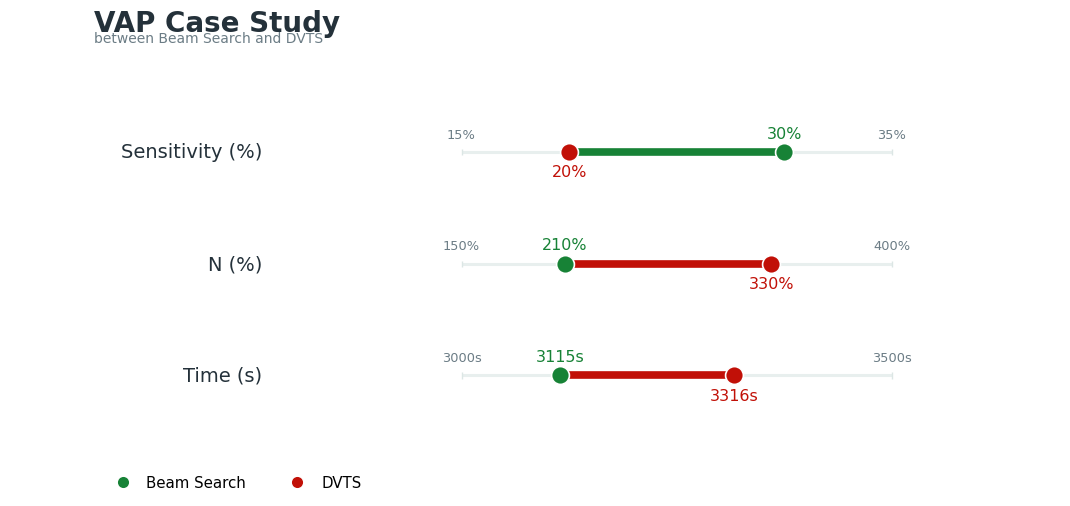

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Fill in your observation
rows = [
    {"metric": "Sensitivity (%)", "Beam Search": 30.0, "DVTS": 20.0, "unit": "%"},
    {"metric": "N (%)",           "Beam Search": 210.0, "DVTS": 330.0, "unit": "%"},
    {"metric": "Time (s)",        "Beam Search": 3114.88263297081, "DVTS": 3316.176517009735, "unit": "s"},
]


C1 = "#178236"   # Color 01
C5 = "#C11007"   # Color 05

TEXT = "#24313A"
SUBTLE = "#6B7C85"
GRID = "#E8EFEE"
SPINE = "#DCE6E5"
BG = "white"

def local_limits(a: float, b: float, unit: str):
    lo = min(a, b)
    hi = max(a, b)
    span = hi - lo
    pad = max(span * 0.45, 1.0)

    xmin = max(0, lo - pad)
    xmax = hi + pad

    if unit == "%":
        step = 5 if xmax <= 50 else 25 if xmax <= 200 else 50
    else:
        step = 50 if xmax <= 1000 else 100

    xmin = math.floor(xmin / step) * step
    xmax = math.ceil(xmax / step) * step

    if xmin == xmax:
        xmax += step

    return xmin, xmax

for r in rows:
    r["xmin"], r["xmax"] = local_limits(r["Beam Search"], r["DVTS"], r["unit"])

fig, ax = plt.subplots(figsize=(10.8, 5.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.set_xlim(0, 1)
ax.set_ylim(-0.82, len(rows) - 0.34)
ax.axis("off")

x_label = 0.24
x0 = 0.43
x1 = 0.84

# Title
ax.text(
    0.08,
    len(rows) - 0.02,
    "VAP Case Study",
    fontsize=20,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="top"
)
ax.text(
    0.08,
    len(rows) - 0.22,
    "between Beam Search and DVTS",
    fontsize=10,
    color=SUBTLE,
    ha="left",
    va="top"
)

# Rows
for idx, r in enumerate(rows):
    y = len(rows) - 1 - idx - 0.30

    ax.text(
        x_label,
        y,
        r["metric"],
        fontsize=14,
        color=TEXT,
        ha="right",
        va="center"
    )

    xmin, xmax = r["xmin"], r["xmax"]

    def map_x(v):
        return x0 + (v - xmin) / (xmax - xmin) * (x1 - x0)

    bx = map_x(r["Beam Search"])
    dx = map_x(r["DVTS"])

    # Light local axis
    ax.hlines(y, x0, x1, color=GRID, linewidth=2.2, zorder=1)
    ax.vlines([x0, x1], y - 0.028, y + 0.028, color=SPINE, linewidth=1.0, zorder=1)

    # Segment colored by the larger value
    seg_color = C1 if r["Beam Search"] >= r["DVTS"] else C5
    ax.hlines(y, min(bx, dx), max(bx, dx), color=seg_color, linewidth=5.5, zorder=2)

    # End points
    ax.scatter([bx], [y], s=165, color=C1, edgecolor="white", linewidth=1.2, zorder=3)
    ax.scatter([dx], [y], s=165, color=C5, edgecolor="white", linewidth=1.2, zorder=3)

    # Labels
    if r["unit"] == "%":
        beam_txt = f"{r['Beam Search']:.0f}%"
        dvts_txt = f"{r['DVTS']:.0f}%"
        xmin_txt = f"{int(xmin)}%"
        xmax_txt = f"{int(xmax)}%"
    else:
        beam_txt = f"{r['Beam Search']:.0f}s"
        dvts_txt = f"{r['DVTS']:.0f}s"
        xmin_txt = f"{int(xmin)}s"
        xmax_txt = f"{int(xmax)}s"

    ax.text(bx, y + 0.10, beam_txt, color=C1, fontsize=11.5, ha="center", va="bottom")
    ax.text(dx, y - 0.11, dvts_txt, color=C5, fontsize=11.5, ha="center", va="top")

    ax.text(x0, y + 0.10, xmin_txt, color=SUBTLE, fontsize=9.3, ha="center", va="bottom")
    ax.text(x1, y + 0.10, xmax_txt, color=SUBTLE, fontsize=9.3, ha="center", va="bottom")

# Legend
legend_items = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C1, markersize=9, label="Beam Search"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C5, markersize=9, label="DVTS"),
]
ax.legend(
    handles=legend_items,
    loc="lower left",
    bbox_to_anchor=(0.08, -0.18),
    frameon=False,
    ncol=2,
    fontsize=10.8,
    columnspacing=2.4,
    handletextpad=0.6,
)

plt.tight_layout()
plt.show()

## Time Analysis

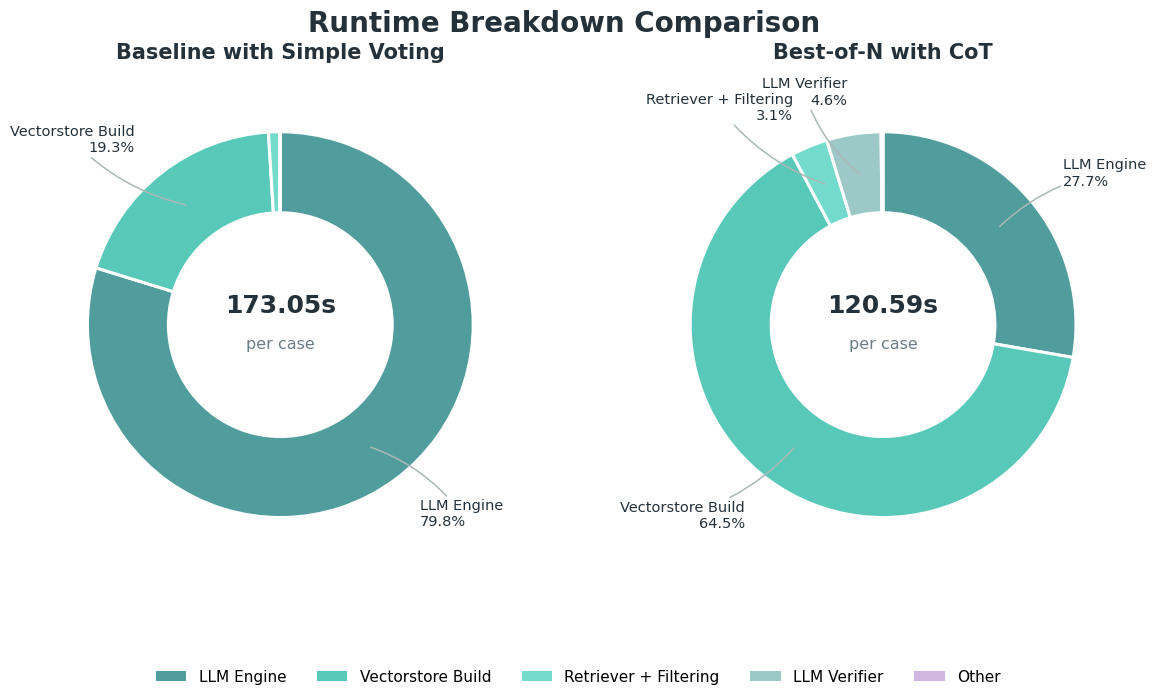

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

C1 = "#519D9E"   # Color 01
C2 = "#58C9B9"   # Color 02
C3 = "#74DBCC"   # Color 03
C4 = "#9DC8C8"   # Color 04
C5 = "#D1B6E1"   # Color 05

palette = {
    "LLM Engine": C1,
    "Vectorstore Build": C2,
    "Retriever + Filtering": C3,
    "LLM Verifier": C4,
    "Other": C5,
}
# Fill in your observation
baseline = {
    "LLM Engine": 690.08,
    "Vectorstore Build": 166.67,
    "Retriever + Filtering": 7.56 + 0.52,
    "LLM Verifier": 0.0,
    "Other": 0.015 + 0.40,
}
baseline_total = 865.25
baseline_cases = 5

cot = {
    "LLM Engine": 4145.88,
    "Vectorstore Build": 9642.38,
    "Retriever + Filtering": 238.82 + 220.26,
    "LLM Verifier": 681.35,
    "Other": 1.34 + 0.21 + 21.67 + 0.17 + 1.46
}
cot_total = 14953.56
cot_cases = 124

order = ["LLM Engine", "Vectorstore Build", "Retriever + Filtering", "LLM Verifier", "Other"]


# =========================================================
# Helper: draw one donut chart
# =========================================================
def draw_donut(ax, data, title, total_seconds, n_cases):
    labels = []
    values = []
    colors = []

    for key in order:
        val = data[key]
        if val > 0:
            labels.append(key)
            values.append(val)
            colors.append(palette[key])

    wedges, _ = ax.pie(
        values,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2.2),
        radius=1.0
    )

    avg_per_case = total_seconds / n_cases

    # center text
    ax.text(
        0, 0.10, f"{avg_per_case:.2f}s",
        ha="center", va="center",
        fontsize=18, fontweight="bold", color="#24313A"
    )
    ax.text(
        0, -0.10, "per case",
        ha="center", va="center",
        fontsize=11.5, color="#6B7C85"
    )

    # title
    ax.set_title(title, fontsize=15, fontweight="bold", color="#24313A", pad=18)

    # external labels for meaningful slices
    total = sum(values)
    for wedge, label, value in zip(wedges, labels, values):
        pct = value / total * 100
        if pct < 2.0:
            continue

        ang = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        r_text = 1.22
        ha = "left" if x >= 0 else "right"

        ax.annotate(
            f"{label}\n{pct:.1f}%",
            xy=(0.79 * x, 0.79 * y),
            xytext=(r_text * x, r_text * y),
            ha=ha,
            va="center",
            fontsize=10.5,
            color="#24313A",
            arrowprops=dict(
                arrowstyle="-",
                color="#AAB8B6",
                lw=1.1,
                shrinkA=0,
                shrinkB=0,
                connectionstyle="arc3,rad=0.15"
            )
        )

    ax.set_aspect("equal")
    ax.set_facecolor("white")


fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor="white")
plt.subplots_adjust(wspace=0.25, bottom=0.18)

draw_donut(
    axes[0],
    baseline,
    "Baseline with Simple Voting",
    baseline_total,
    baseline_cases
)

draw_donut(
    axes[1],
    cot,
    "Best-of-N with CoT",
    cot_total,
    cot_cases
)

# shared legend
legend_handles = [Patch(facecolor=palette[k], edgecolor="none", label=k) for k in order]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=11
)

# overall title
fig.suptitle(
    "Runtime Breakdown Comparison",
    fontsize=20,
    fontweight="bold",
    color="#24313A",
    y=0.98
)

plt.show()